<!-- launch-badges -->
<a href="https://colab.research.google.com/github/laban254/ml-for-infrastructure/blob/main/04_deep_learning/pytorch/05_timeseries_lstm.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
&nbsp;
<a href="https://mybinder.org/v2/gh/laban254/ml-for-infrastructure/main?urlpath=lab/tree/04_deep_learning/pytorch/05_timeseries_lstm.ipynb" target="_blank"><img src="https://mybinder.org/badge_logo.svg" alt="Open in Binder"/></a>

> ▶️ **Run this notebook live** — no install needed. Click a badge above to open it in a free cloud runtime.

# Time Series Forecasting for Infrastructure Metrics

## Context
Unlike tabular ML problems where each row is treated as an independent, identically-distributed (i.i.d.) sample, infrastructure metrics like CPU usage are **sequential** — the value at any given minute is correlated with recent history and tends to repeat in daily/weekly cycles. An LSTM (Long Short-Term Memory) network is a recurrent architecture designed specifically to exploit this kind of temporal autocorrelation, carrying relevant context forward through a sequence rather than treating each observation in isolation.

## Objectives
- Build a predictive model using an **LSTM (Long Short-Term Memory)** neural network in PyTorch.
- Forecast future infrastructure load (e.g., CPU utilization) based on historical sequence data.
- Learn how to flag anomalies when the actual metric deviates significantly from the LSTM's prediction.

## Dataset
- We will generate a synthetic time series of CPU usage showing daily patterns and injected anomalies.

## Expected Outcome
- A trained PyTorch LSTM model capable of predicting the next hour of CPU load.
- A visualization comparing the predicted vs. actual load to spot anomalies.

## Challenge
- Later in this notebook we go beyond single-step prediction: a recursive 30-minute multi-step forecast, followed by an exercise that turns that forecast into a pre-emptive scale-up alert whenever predicted CPU is expected to cross a 75% threshold.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set seeds
torch.manual_seed(42)
np.random.seed(42)

print(f"Using device: {device}")

Using device: cpu


### 1. Generating Data
We need a time series with a clear pattern that an LSTM can learn.

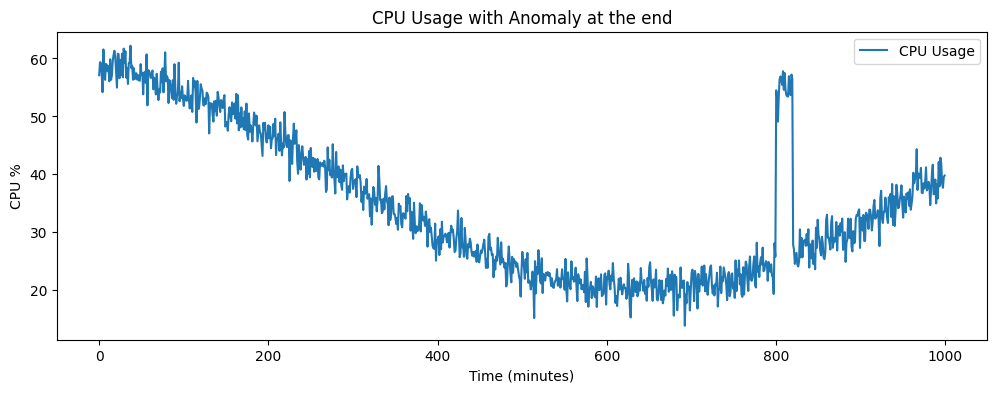

In [2]:
def generate_cpu_metrics(days=14, points_per_hour=60):
    total_points = days * 24 * points_per_hour
    t = np.linspace(0, days * 2 * np.pi, total_points)
    
    # Base daily sine wave
    base_load = 40 + 20 * np.sin(t)
    
    # Add noise
    noise = np.random.normal(0, 2, total_points)
    
    cpu_usage = base_load + noise
    
    # Inject an anomaly near the end
    cpu_usage[-200:-180] += 30
    
    return np.clip(cpu_usage, 0, 100).reshape(-1, 1)

data = generate_cpu_metrics()

plt.figure(figsize=(12, 4))
plt.plot(data[-1000:], label="CPU Usage") # Plot last ~16 hours
plt.title("CPU Usage with Anomaly at the end")
plt.xlabel("Time (minutes)")
plt.ylabel("CPU %")
plt.legend()
plt.show()

### 2. Preprocessing for PyTorch
Neural networks train best when data is scaled between -1 and 1 or 0 and 1.

In [3]:
# Function to create sequences
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data)-seq_length-1):
        x = data[i:(i+seq_length)]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 60 # Look back 60 minutes to predict the next 1 minute

# Figure out the chronological train/test split BEFORE fitting the scaler.
# Fitting MinMaxScaler on the full series (train + test) would leak the
# test-period min/max into the training preprocessing — a classic time-series
# leakage bug. Instead we fit only on the training slice and .transform() the rest.
n_sequences = len(data) - SEQ_LENGTH - 1     # how many (X, y) sequences we'll end up with
train_size = int(n_sequences * 0.8)
split_idx = train_size + SEQ_LENGTH          # raw-data index marking the end of the training slice

scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(data[:split_idx])          # fit on training slice only
scaled_data = scaler.transform(data)  # transform the full series with those train-derived stats

X, y = create_sequences(scaled_data, SEQ_LENGTH)

# Split into train/test (chronologically! Don't shuffle time series data initially)
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

# Convert to PyTorch tensors
X_train = torch.from_numpy(X_train).float().to(device)
y_train = torch.from_numpy(y_train).float().to(device)
X_test = torch.from_numpy(X_test).float().to(device)
y_test = torch.from_numpy(y_test).float().to(device)

# Create DataLoaders
batch_size = 64
train_data = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_data, shuffle=True, batch_size=batch_size)

### 3. Defining the LSTM Model

In [4]:
class CPUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, output_size=1):
        super(CPUForecaster, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # Initialize hidden state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        
        # Note: h0/c0 are freshly created (zero) tensors on every forward() call, so no
        # hidden state is actually carried over between batches here — the .detach()
        # calls below are no-ops for this model. Detaching the hidden state matters for
        # *stateful* RNNs that intentionally carry hidden state across batches, where
        # skipping it would backprop all the way through the entire training history.
        out, _ = self.lstm(x, (h0.detach(), c0.detach()))
        
        # Index hidden state of last time step
        out = self.fc(out[:, -1, :]) 
        return out

model = CPUForecaster().to(device)
criterion = nn.MSELoss() # Mean Squared Error is standard for regression/time-series
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### 4. Training Loop

In [5]:
epochs = 10

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    if (epoch+1) % 2 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.4f}')

Epoch [2/10], Loss: 0.0065


Epoch [4/10], Loss: 0.0066


Epoch [6/10], Loss: 0.0066


Epoch [8/10], Loss: 0.0065


Epoch [10/10], Loss: 0.0065


*Note:* the loss drops sharply after epoch 1 and then plateaus/gets a bit noisy for the rest of training — that's expected here. The underlying signal is just a clean sine wave (plus a little Gaussian noise), so the model converges almost immediately and there isn't much more pattern left to learn in later epochs.

### 5. Evaluation and Anomaly Detection
When a model accurately predicts the time series, a sudden large gap between `Actual` and `Predicted` indicates an anomaly.

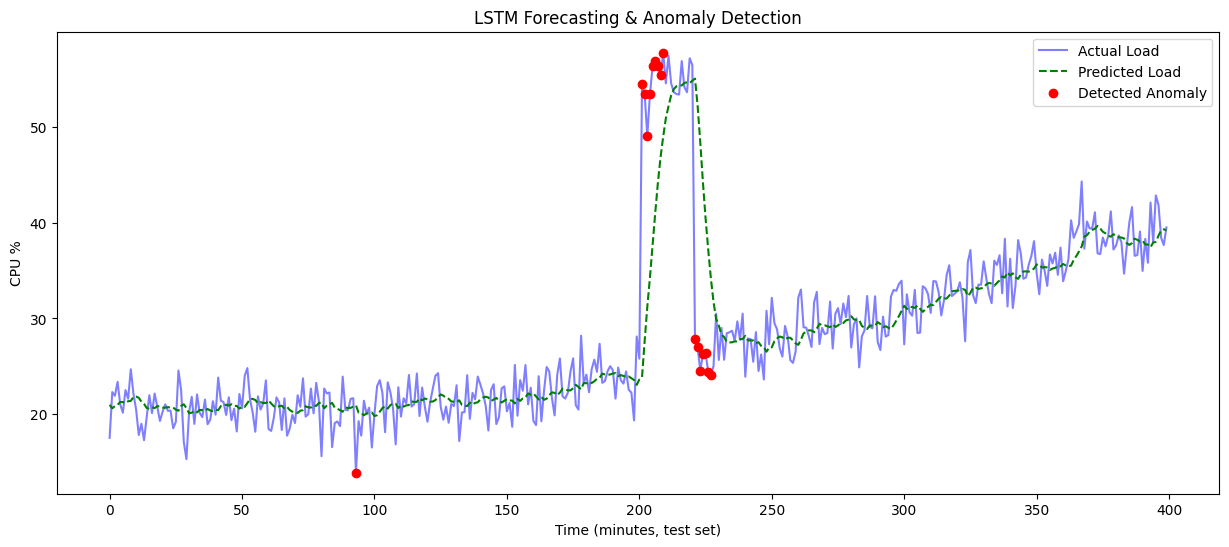

In [6]:
model.eval()
with torch.no_grad():
    test_predictions = model(X_test)

# Inverse transform to get back to original CPU percentages
predictions_inv = scaler.inverse_transform(test_predictions.cpu().numpy())
y_test_inv = scaler.inverse_transform(y_test.cpu().numpy())

# Calculate Error
errors = np.abs(predictions_inv - y_test_inv)
threshold = np.mean(errors) + 3 * np.std(errors) # 3 standard deviations for anomaly threshold

# Plot the last 400 points of the test set
points_to_plot = 400
plt.figure(figsize=(15, 6))

plt.plot(y_test_inv[-points_to_plot:], label='Actual Load', alpha=0.5, color='blue')
plt.plot(predictions_inv[-points_to_plot:], label='Predicted Load', linestyle='dashed', color='green')

# Highlight points where error > threshold
recent_errors = errors[-points_to_plot:]
anomalies = np.where(recent_errors > threshold)[0]
plt.scatter(anomalies, y_test_inv[-points_to_plot:][anomalies], color='red', label='Detected Anomaly', zorder=5)

plt.title("LSTM Forecasting & Anomaly Detection")
plt.xlabel("Time (minutes, test set)")
plt.ylabel("CPU %")
plt.legend()
plt.show()

### 6. How good is the forecast, in real units?

A loss of `0.002` on scaled data is meaningless to an operator. Let's report the error back in **CPU %** — Mean Absolute Error (typical miss) and RMSE (which punishes large misses). Then look at the error distribution: the long right tail *is* the anomaly we injected.

MAE : 1.76 %CPU  (the model is typically off by this much)
RMSE: 2.44 %CPU
Anomaly threshold (mean + 3σ): 6.85 %CPU


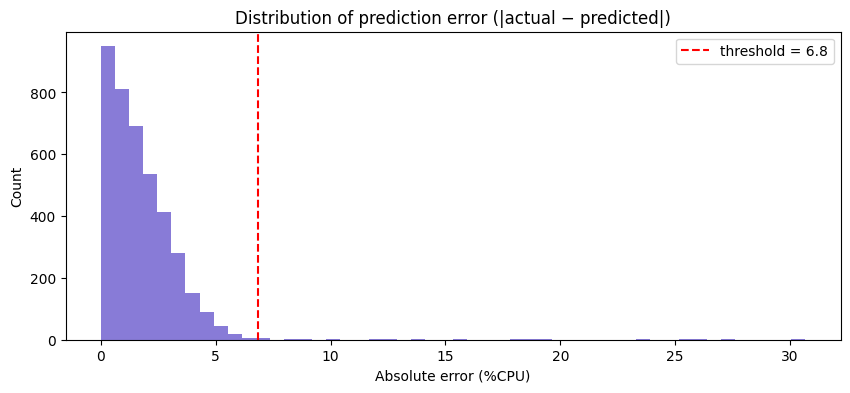

In [7]:
mae = np.mean(np.abs(predictions_inv - y_test_inv))
rmse = np.sqrt(np.mean((predictions_inv - y_test_inv) ** 2))
print(f'MAE : {mae:.2f} %CPU  (the model is typically off by this much)')
print(f'RMSE: {rmse:.2f} %CPU')
print(f'Anomaly threshold (mean + 3σ): {threshold:.2f} %CPU')

plt.figure(figsize=(10, 4))
plt.hist(errors, bins=50, color='slateblue', alpha=0.8)
plt.axvline(threshold, color='red', ls='--', label=f'threshold = {threshold:.1f}')
plt.title('Distribution of prediction error (|actual − predicted|)')
plt.xlabel('Absolute error (%CPU)'); plt.ylabel('Count'); plt.legend()
plt.show()

### 7. Multi-step forecasting (the Challenge)

So far the model predicts **one** step ahead. To forecast the *next 30 minutes* we forecast recursively: predict one minute, append that prediction to the input window, slide it forward, and predict again. Watch the uncertainty compound — each prediction is now built partly on previous predictions, not ground truth.

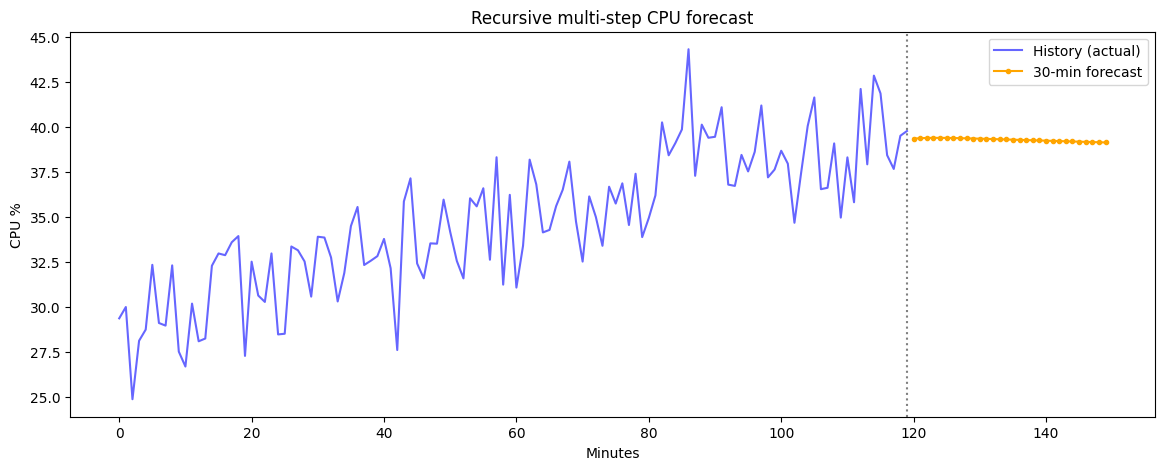

In [8]:
model.eval()
horizon = 30                       # forecast 30 minutes into the future
window = scaled_data[-SEQ_LENGTH:].copy()   # last known minute-by-minute window
future_scaled = []

with torch.no_grad():
    for _ in range(horizon):
        x = torch.from_numpy(window).float().unsqueeze(0).to(device)  # (1, seq, 1)
        nxt = model(x).cpu().numpy()                                  # (1, 1)
        future_scaled.append(nxt[0, 0])
        window = np.vstack([window[1:], nxt])      # slide window forward

future = scaler.inverse_transform(np.array(future_scaled).reshape(-1, 1))
history = scaler.inverse_transform(scaled_data[-120:])

plt.figure(figsize=(14, 5))
plt.plot(range(len(history)), history, label='History (actual)', color='blue', alpha=0.6)
plt.plot(range(len(history), len(history) + horizon), future,
         label=f'{horizon}-min forecast', color='orange', marker='o', ms=3)
plt.axvline(len(history) - 1, color='gray', ls=':')
plt.title('Recursive multi-step CPU forecast')
plt.xlabel('Minutes'); plt.ylabel('CPU %'); plt.legend(); plt.show()

## 📝 Exercise: turn the forecast into a capacity alert

Forecasting is only useful if it drives action. **Using the 30-minute `future` forecast, decide whether to fire a pre-emptive scale-up alert** — say, if CPU is predicted to cross 75% at any point in the next half hour. Print *when* the breach is expected.

```python
# your code here
```

<details><summary>💡 Reveal solution</summary>

```python
limit = 75
breaches = np.where(future.flatten() > limit)[0]
if len(breaches):
    print(f'⚠️  SCALE-UP: CPU predicted to exceed {limit}% in ~{breaches[0]} min')
else:
    print(f'✅ No breach of {limit}% predicted in the next {horizon} minutes')
```

This is the bridge from a model to an action: a forecast that crosses a capacity line *before* it happens is what lets you autoscale ahead of the load instead of reacting after users are already seeing latency.
</details>